Generating 200000 events, 3 outgoing particles, w = 100, masses = [5 5 5]


C:\Users\nicho\AppData\Local\Temp\ipykernel_28912\3137447978.py:129: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(y[mask], x[mask])


Saved: rambo_validation.png


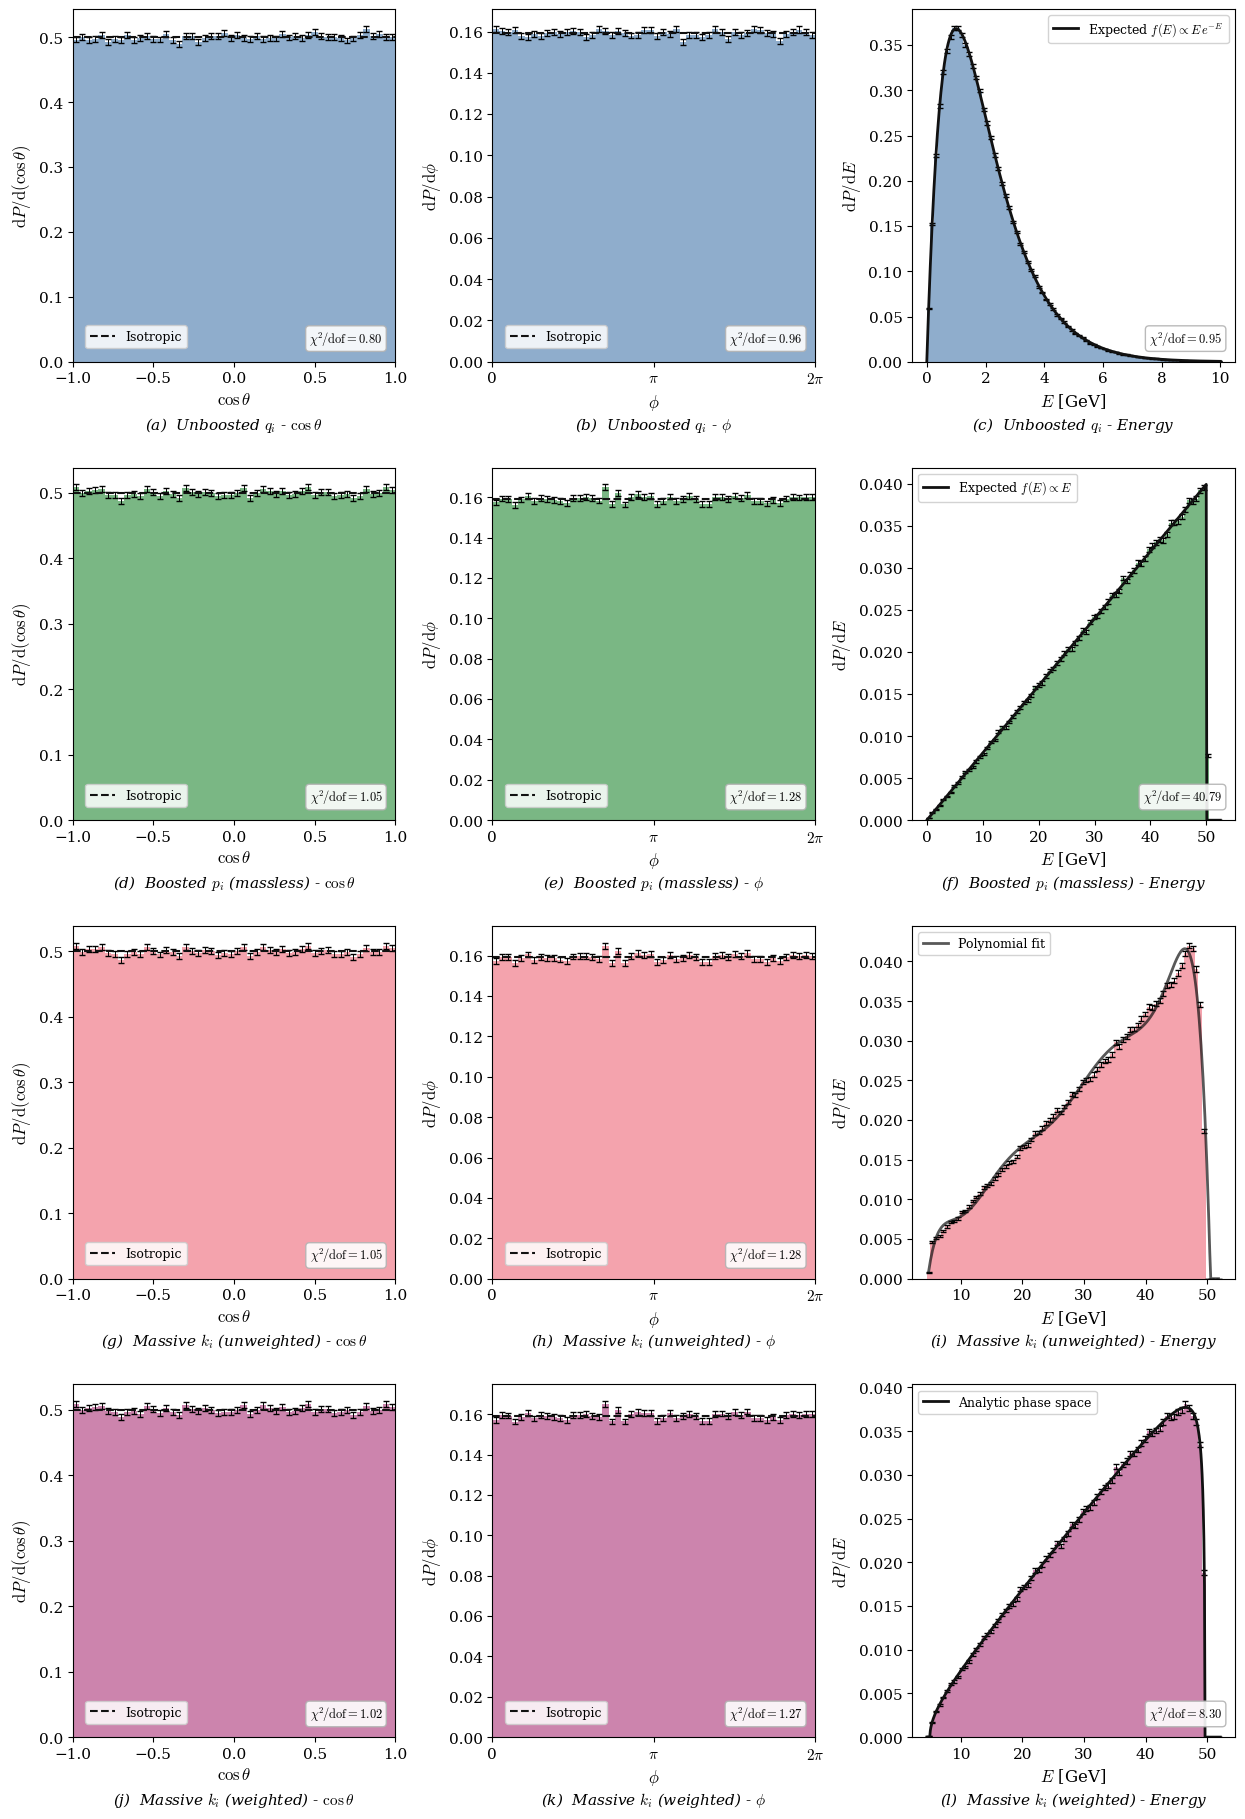

In [4]:
"""
RAMBO Phase Space Validation — 4 stages x 3 distributions
==========================================================
Rows:    unboosted q | boosted p | massive k (unweighted) | massive k (weighted)
Columns: cos(theta)  | phi       | energy
 
Analytic expected curves overlaid. Thesis-ready labelling (a)–(l).
"""
 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from numpy.polynomial import polynomial as P
from mc_integration import massless_momenta_generation, massive_transform
 
 
# ============================================================
# Parameters
# ============================================================
 
N_events = 200_000
n_out = 3
w = 100
masses = np.array([5,5,5])  # equal masses
m = masses[0]  # equal masses
bins = 50

print(f"Generating {N_events} events, {n_out} outgoing particles, w = {w}, masses = {masses}")
 
 
# ============================================================
# Generate events — store all four stages
# ============================================================
 
unboosted_all = []
boosted_all = []
massive_all = []
massive_wts = []
 
for _ in range(N_events):
    rho_1, rho_2, rho_3, rho_4 = np.random.rand(4, n_out)
    c = 2 * rho_1 - 1
    s = np.sqrt(1 - c**2)
    phi = 2 * np.pi * rho_2
    q_0 = -np.log(rho_3 * rho_4)
    q_list = np.empty((n_out, 4))
    q_list[:, 0] = q_0
    q_list[:, 1] = q_0 * s * np.cos(phi)
    q_list[:, 2] = q_0 * s * np.sin(phi)
    q_list[:, 3] = q_0 * c
    unboosted_all.append(q_list)
 
    Q_0, Q_1, Q_2, Q_3 = np.sum(q_list, axis=0)
    M = np.sqrt(Q_0**2 - Q_1**2 - Q_2**2 - Q_3**2)
    gamma_val = Q_0 / M
    x = w / M
    a = 1 / (1 + gamma_val)
    b_v = -np.array([Q_1, Q_2, Q_3]) / M
    q_v = q_list[:, 1:4]
    b_dot_q = q_v @ b_v
    p_0 = x * (gamma_val * q_0 + b_dot_q)
    p_v = x * (q_v + b_v * q_0[:, None] + a * b_dot_q[:, None] * b_v)
    p_list = np.column_stack([p_0, p_v])
    boosted_all.append(p_list)
 
    k_list, wt = massive_transform(w, n_out, p_list, masses)
    massive_all.append(k_list)
    massive_wts.append(wt)
 
unboosted_all = np.vstack(unboosted_all)
boosted_all = np.vstack(boosted_all)
massive_all = np.vstack(massive_all)
massive_wts = np.array(massive_wts)
weights_per_particle = np.repeat(massive_wts, n_out)
 
 
# ============================================================
# Analytic expected distributions
# ============================================================
 
def analytic_unboosted_energy(E):
    """Gamma(2,1) PDF: f(E) = E exp(-E)."""
    return E * np.exp(-E)
 
 
def analytic_boosted_energy(E, w, n):
    """
    Single-particle energy marginal in massless n-body LIPS:
        f(E) ∝ E (w² - 2wE)^{n-3}   for E ∈ [0, w/2]
    """
    return np.where(
        (E >= 0) & (E <= w / 2),
        E * (w**2 - 2 * w * E) ** max(n - 3, 0),
        0.0,
    )
 
 
def analytic_massive_weighted_energy(E, w, m):
    """
    Single-particle energy marginal for 3-body LIPS, equal masses m.
 
    Derived by integrating out the 2-body sub-system.  The recoiling
    pair has squared invariant mass  s' = w² + m² - 2wE,  and 2-body
    phase space  R₂(s') ∝ sqrt(s' - 4m²) / sqrt(s').  Combined with
    the single-particle measure d³k/(2E) ∝ |k| dE:
 
        f(E) ∝ sqrt(E² - m²) · sqrt(s' - 4m²) / sqrt(s')
 
    Kinematic limits:
        E_min = m                    (particle at rest in CM)
        E_max = (w² - 3m²) / (2w)   (recoil pair at threshold)
    """
    sp = w**2 + m**2 - 2 * w * E
    E_min = m
    E_max = (w**2 - 3 * m**2) / (2 * w)
    mask = (E >= E_min) & (E <= E_max) & (sp > 4 * m**2)
    result = np.zeros_like(E, dtype=float)
    result[mask] = (
        np.sqrt(E[mask]**2 - m**2)
        * np.sqrt(sp[mask] - 4 * m**2)
        / np.sqrt(sp[mask])
    )
    return result
 
 
def normalise_curve(x, y, data_range):
    """Normalise an analytic curve to integrate to 1 over data_range."""
    mask = (x >= data_range[0]) & (x <= data_range[1])
    integral = np.trapz(y[mask], x[mask])
    if integral > 0:
        y = y / integral
    return y
 
 
# ============================================================
# Helper functions
# ============================================================
 
def get_angles(momenta):
    p3 = momenta[:, 1:4]
    r = np.linalg.norm(p3, axis=1)
    mask = r > 0
    cos_theta = p3[mask, 2] / r[mask]
    phi = np.arctan2(p3[mask, 1], p3[mask, 0])
    phi[phi < 0] += 2 * np.pi
    return cos_theta, phi, mask
 
 
def hist_data(values, bins, range, weights=None):
    counts, edges = np.histogram(values, bins=bins, range=range, weights=weights)
    width = edges[1] - edges[0]
    centers = (edges[:-1] + edges[1:]) / 2
    if weights is not None:
        counts2, _ = np.histogram(values, bins=bins, range=range,
                                  weights=weights**2)
        norm = counts.sum() * width
        density = counts / norm
        err = np.sqrt(counts2) / norm
    else:
        norm = len(values) * width
        density = counts / norm
        err = np.sqrt(counts) / norm
    return centers, density, err, width
 
 
def chi2_per_dof(observed, expected, errors, n_params=0):
    mask = errors > 0
    residuals = (observed[mask] - expected[mask]) / errors[mask]
    ndof = mask.sum() - n_params
    if ndof <= 0:
        return np.nan
    return np.sum(residuals**2) / ndof
 
 
# ============================================================
# Extract distributions
# ============================================================
 
stages = []
 
cos_u, phi_u, _ = get_angles(unboosted_all)
stages.append({
    'label': r'Unboosted $q_i$',
    'cos': cos_u, 'phi': phi_u,
    'energy': unboosted_all[:, 0],
    'weights': None,
    'E_range': (0, 10),
    'E_analytic': (r'Expected $f(E) \propto E\,e^{-E}$',
                   analytic_unboosted_energy),
})
 
cos_b, phi_b, _ = get_angles(boosted_all)
stages.append({
    'label': r'Boosted $p_i$ (massless)',
    'cos': cos_b, 'phi': phi_b,
    'energy': boosted_all[:, 0],
    'weights': None,
    'E_range': (0, w / 2 * 1.05),
    'E_analytic': (r'Expected $f(E) \propto E$',
                   lambda E: analytic_boosted_energy(E, w, n_out)),
})
 
cos_m, phi_m, mask_m = get_angles(massive_all)
stages.append({
    'label': r'Massive $k_i$ (unweighted)',
    'cos': cos_m, 'phi': phi_m,
    'energy': massive_all[:, 0],
    'weights': None,
    'E_range': (masses.min() * 0.9,
                (w**2 - 3 * m**2) / (2 * w) * 1.05),
    'E_analytic': None,
})
 
stages.append({
    'label': r'Massive $k_i$ (weighted)',
    'cos': cos_m, 'phi': phi_m,
    'energy': massive_all[:, 0],
    'weights': weights_per_particle[mask_m],
    'weights_E': weights_per_particle,
    'E_range': (masses.min() * 0.9,
                (w**2 - 3 * m**2) / (2 * w) * 1.05),
    'E_analytic': (r'Analytic phase space',
                   lambda E: analytic_massive_weighted_energy(E, w, m)),
})
 
 
# ============================================================
# Visual configuration
# ============================================================
 
# Row colours — each RAMBO stage gets a distinct hue so the
# reader can visually track the progression through the algorithm.
# Blue → green → orange → purple maps to:
#   raw sampling → boosted → conformal rescale → physical reweighting
ROW_COLOURS = ['#4477AA', '#228833', '#EE6677', '#AA3377']
 
# Theory curves always black for contrast
THEORY_COLOUR = '#111111'
 
# Panel labels: (a)–(l), row-major.  Standard for multi-panel
# thesis figures so each panel can be cited individually.
PANEL_LABELS = [chr(ord('a') + i) for i in range(12)]
 
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.linewidth': 0.8,
})

COL_LABELS = [r'$\cos\theta$', r'$\phi$', r'Energy']
 
 
# ============================================================
# Plot: 4 rows × 3 columns
# ============================================================
 
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
fig.subplots_adjust(hspace=0.3, wspace=0.3, top=0.99, bottom=0.03)
 
#fig.suptitle(r"RAMBO Phase-Space Validation"f"    ($N = {N_events/1e3:.0f}$k,  $n = {n_out}$,  "
#             rf"$\sqrt{{s}} = {w:.0f}$ GeV,  $m_i = {m:.0f}$ GeV)",fontsize=14, fontweight='bold',)
 
for row, st in enumerate(stages):
    w_ang = st.get('weights', None)
    w_E = st.get('weights_E', st.get('weights', None))
    colour = ROW_COLOURS[row]
 
    for col in range(3):
        ax = axes[row, col]
        idx = row * 3 + col
 
        # ============ cos(theta) ============
        if col == 0:
            c, d, e, bw = hist_data(st['cos'], bins, (-1, 1),
                                    weights=w_ang)
            ax.bar(c, d, width=bw, alpha=0.6, color=colour,
                   edgecolor='none')
            ax.errorbar(c, d, yerr=e, fmt='none', ecolor='k',
                        capsize=2, lw=0.7)
            expected = np.full_like(d, 0.5)
            ax.axhline(0.5, color=THEORY_COLOUR, ls='--', lw=1.5,
                       label='Isotropic')
            chi2 = chi2_per_dof(d, expected, e)
            ax.legend(loc='lower left', framealpha=0.85, bbox_to_anchor=(0.02, 0.02))
            ax.text(0.96, 0.04,
                    rf'$\chi^2\!/\mathrm{{dof}} = {chi2:.2f}$',
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3',
                              fc='white', ec='0.7', alpha=0.9))
            ax.set_xlim(-1, 1)
            ax.set_xlabel(r'$\cos\theta$')
            ax.set_ylabel(r'$\mathrm{d}P / \mathrm{d}(\cos\theta)$')
 
        # ============ phi ============
        elif col == 1:
            c, d, e, bw = hist_data(st['phi'], bins, (0, 2*np.pi),
                                    weights=w_ang)
            ax.bar(c, d, width=bw, alpha=0.6, color=colour,
                   edgecolor='none')
            ax.errorbar(c, d, yerr=e, fmt='none', ecolor='k',
                        capsize=2, lw=0.7)
            expected_phi = 1.0 / (2 * np.pi)
            expected = np.full_like(d, expected_phi)
            ax.axhline(expected_phi, color=THEORY_COLOUR, ls='--',
                       lw=1.5, label='Isotropic')
            chi2 = chi2_per_dof(d, expected, e)
            ax.legend(loc='lower left', framealpha=0.85, bbox_to_anchor=(0.02, 0.02))
            ax.text(0.96, 0.04,
                    rf'$\chi^2\!/\mathrm{{dof}} = {chi2:.2f}$',
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3',
                              fc='white', ec='0.7', alpha=0.9))
            ax.set_xlim(0, 2 * np.pi)
            ax.set_xlabel(r'$\phi$')
            ax.set_ylabel(r'$\mathrm{d}P / \mathrm{d}\phi$')
            ax.xaxis.set_major_locator(MultipleLocator(np.pi))
            ax.xaxis.set_major_formatter(plt.FuncFormatter(
                lambda val, _: {0: '0', 1: r'$\pi$',
                                2: r'$2\pi$'}.get(
                    int(round(val / np.pi)),
                    f'{val/np.pi:.1f}$\\pi$')
            ))
 
        # ============ energy ============
        else:
            E_bins = 80
            c, d, e, bw = hist_data(st['energy'], E_bins,
                                    st['E_range'], weights=w_E)
            ax.bar(c, d, width=bw, alpha=0.6, color=colour,
                   edgecolor='none')
            ax.errorbar(c, d, yerr=e, fmt='none', ecolor='k',
                        capsize=2, lw=0.7)
 
            if st.get('E_analytic') is not None:
                label, func = st['E_analytic']
                x_curve = np.linspace(st['E_range'][0],
                                      st['E_range'][1], 500)
                y_curve = func(x_curve)
                y_curve = normalise_curve(x_curve, y_curve,
                                         st['E_range'])
                ax.plot(x_curve, y_curve, color=THEORY_COLOUR,
                        lw=2, label=label)
                # χ² against analytic at bin centres
                y_exp = func(c)
                y_exp = normalise_curve(c, y_exp, st['E_range'])
                chi2 = chi2_per_dof(d, y_exp, e)
                ax.text(0.96, 0.04,
                        rf'$\chi^2\!/\mathrm{{dof}} = {chi2:.2f}$',
                        transform=ax.transAxes, ha='right', va='bottom',
                        fontsize=9,
                        bbox=dict(boxstyle='round,pad=0.3',
                                  fc='white', ec='0.7', alpha=0.9))
            else:
                # Polynomial fit for massive unweighted
                mask_fit = d > 0
                coeffs = P.polyfit(c[mask_fit], d[mask_fit], 8)
                x_s = np.linspace(c[0], c[-1], 300)
                y_s = np.maximum(P.polyval(x_s, coeffs), 0)
                ax.plot(x_s, y_s, color=THEORY_COLOUR, lw=2,
                        alpha=0.7, label='Polynomial fit')
 
            ax.legend(loc='upper left' if row != 0 else 'upper right', framealpha=0.85, borderaxespad=0.5,)# bbox_to_anchor=(0.02, 0.02))
            ax.set_xlabel(r'$E$ [GeV]')
            ax.set_ylabel(r'$\mathrm{d}P / \mathrm{d}E$')
 
        # ---- Panel caption beneath the axis ----
        letter = PANEL_LABELS[idx]
        ax.text(0.5, -0.15,
                f'({letter})  {st["label"]} - {COL_LABELS[col]}',
                transform=ax.transAxes, ha='center', va='top',
                fontsize=11, fontstyle='italic')
 
fig.savefig('rambo_validation.png', dpi=150, bbox_inches='tight', pad_inches = 0.1)
print("Saved: rambo_validation.png")
plt.show()